Raw Insurance Data
        ↓
Data Cleaning
        ↓
Feature Engineering
        ↓
Encoding + NLP
        ↓
Train/Test Split
        ↓
SMOTE Balancing
        ↓
Model Training
        ↓
Evaluation
        ↓
Fraud Probability Score
        ↓
Explainable Fraud Alerts

In [ ]:
import pandas as pd
import numpy as np



In [ ]:
dataset = pd.read_csv('/content/Final_insurance_fraud.csv')

In [ ]:
dataset.head()

,Claim_ID,Customer_Age,Claim_Amount,Claim_History,Policy_Type,Incident_Severity,Claim_Frequency,Fraud_Label,Claim_Description,Gender,...,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Deductible,Policy Type,Customer Preferences,Preferred Communication Channel,Driving Record,Life Events
0,C100000,58.0,20604.0,0.0,Auto,Severe,3.0,0.0,Enjoy four run family hundred number. Say mana...,Female,...,Phone,policy2,366603,2749,1604,Group,Email,In-Person Meeting,DUI,Job Change
1,C100001,71.0,17923.0,0.0,Auto,Moderate,3.0,0.0,Peace play attention he box information agree....,Male,...,Chat,policy1,780236,1966,1445,Group,Mail,In-Person Meeting,Clean,Retirement
2,C100002,48.0,48591.0,4.0,Health,Severe,9.0,0.0,Medical likely we course. Claim less from will...,Female,...,Email,policy3,773926,4413,1612,Group,Email,Mail,Accident,Childbirth
3,C100003,34.0,9547.0,2.0,Home,Severe,1.0,0.0,Improve bad experience exist.\nMove message be...,Male,...,Chat,policy2,787815,4342,1817,Family,Text,In-Person Meeting,DUI,Job Change
4,C100004,62.0,45283.0,1.0,Auto,Severe,7.0,0.0,Gun subject perhaps agency pretty. Food sing d...,Female,...,Chat,policy4,366506,1276,133,Family,Email,Text,Major Violations,Childbirth


In [ ]:
dataset.shape


(5061, 29)

In [ ]:
dataset.describe()

,Customer_Age,Claim_Amount,Claim_History,Claim_Frequency,Fraud_Label,Income Level,Location,Coverage Amount,Premium Amount,Deductible
count,4991.000000,4980.000000,4991.000000,4980.000000,4988.000000,5061.000000,5061.000000,5061.000000,5061.000000,5061.000000
mean,49.708275,25533.898193,2.005810,4.966265,0.152366,83703.020352,53699.293223,492450.577751,2996.743529,1120.382928
std,17.265133,14095.911120,1.429073,2.556308,0.359411,36877.433704,25534.442975,268419.981214,1285.980894,559.827241
min,20.000000,1016.000000,0.000000,1.000000,0.000000,20001.000000,10000.000000,50001.000000,529.000000,100.000000
25%,35.000000,13392.000000,1.000000,3.000000,0.000000,52179.000000,31226.000000,244318.000000,1790.000000,675.000000
50%,50.000000,25523.000000,2.000000,5.000000,0.000000,82434.000000,55672.000000,475219.000000,3165.000000,1142.000000
75%,65.000000,37746.000000,3.000000,7.000000,0.000000,116595.000000,75070.000000,737669.000000,4271.000000,1615.000000
max,79.000000,49994.000000,4.000000,9.000000,1.000000,149999.000000,99605.000000,1000000.000000,5000.000000,2000.000000


In [ ]:
dataset['Fraud_Label'].value_counts()

,count
Fraud_Label,
0.0,4228
1.0,760


In [ ]:
from enum import unique
dataset.isnull().sum(),unique

(Claim_ID                              69
 Customer_Age                          70
 Claim_Amount                          81
 Claim_History                         70
 Policy_Type                           75
 Incident_Severity                     75
 Claim_Frequency                       81
 Fraud_Label                           73
 Claim_Description                     73
 Gender                                 0
 Marital Status                         0
 Occupation                             0
 Income Level                           0
 Education Level                        0
 Location                               0
 Behavioral Data                        0
 Purchase History                       0
 Policy Start Date                      0
 Policy Renewal Date                    0
 Interactions with Customer Service     0
 Insurance Products Owned               0
 Coverage Amount                        0
 Premium Amount                         0
 Deductible                       

In [ ]:
dataset.isnull().sum()

,0
Claim_ID,69
Customer_Age,70
Claim_Amount,81
Claim_History,70
Policy_Type,75
Incident_Severity,75
Claim_Frequency,81
Fraud_Label,73
Claim_Description,73
Gender,0


#To Handle the missing data



In [ ]:
# Dropping where fraud label is not there
dataset = dataset.dropna(subset=['Fraud_Label'])

#Numerical Columns
num_cols = [
    'Customer_Age',
    'Claim_Amount',
    'Claim_History',
    'Claim_Frequency'
]

for col in num_cols:
    dataset[col] = dataset[col].fillna(dataset[col].median())


#Categorical Columns
cat_cols = [
    'Policy_Type',
    'Incident_Severity'
]

for col in cat_cols:
    dataset[col] = dataset[col].fillna(dataset[col].mode()[0])

# Description column

dataset['Claim_Description'] = dataset['Claim_Description'].fillna('')

In [ ]:
dataset.isnull().sum()

,0
Claim_ID,8
Customer_Age,0
Claim_Amount,0
Claim_History,0
Policy_Type,0
Incident_Severity,0
Claim_Frequency,0
Fraud_Label,0
Claim_Description,0
Gender,0


In [ ]:
dataset.head()

,Claim_ID,Customer_Age,Claim_Amount,Claim_History,Policy_Type,Incident_Severity,Claim_Frequency,Fraud_Label,Claim_Description,Gender,...,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Deductible,Policy Type,Customer Preferences,Preferred Communication Channel,Driving Record,Life Events
0,C100000,58.0,20604.0,0.0,Auto,Severe,3.0,0.0,Enjoy four run family hundred number. Say mana...,Female,...,Phone,policy2,366603,2749,1604,Group,Email,In-Person Meeting,DUI,Job Change
1,C100001,71.0,17923.0,0.0,Auto,Moderate,3.0,0.0,Peace play attention he box information agree....,Male,...,Chat,policy1,780236,1966,1445,Group,Mail,In-Person Meeting,Clean,Retirement
2,C100002,48.0,48591.0,4.0,Health,Severe,9.0,0.0,Medical likely we course. Claim less from will...,Female,...,Email,policy3,773926,4413,1612,Group,Email,Mail,Accident,Childbirth
3,C100003,34.0,9547.0,2.0,Home,Severe,1.0,0.0,Improve bad experience exist.\nMove message be...,Male,...,Chat,policy2,787815,4342,1817,Family,Text,In-Person Meeting,DUI,Job Change
4,C100004,62.0,45283.0,1.0,Auto,Severe,7.0,0.0,Gun subject perhaps agency pretty. Food sing d...,Female,...,Chat,policy4,366506,1276,133,Family,Email,Text,Major Violations,Childbirth


In [ ]:
# Convert and format dates to MM-DD-YY
dataset["Purchase History"] = pd.to_datetime(dataset["Purchase History"], errors="coerce").dt.strftime("%m-%d-%y");
dataset["Policy Start Date"] = pd.to_datetime(dataset["Policy Start Date"], errors="coerce").dt.strftime("%m-%d-%y");
dataset["Policy Renewal Date"] = pd.to_datetime(dataset["Policy Renewal Date"], errors="coerce").dt.strftime("%m-%d-%y")

In [ ]:
dataset['Purchase History'].head(20)


,Purchase History
0,04-10-18
1,11-06-18
2,06-05-21
3,09-02-18
4,09-10-18
5,09-19-20
6,07-04-21
7,11-01-21
8,09-20-20
9,04-24-20


In [ ]:
dataset['Policy Renewal Date'].head(20)

,Policy Renewal Date
0,12-03-23
1,06-09-23
2,11-03-24
3,05-04-23
4,09-10-23
5,04-16-24
6,01-02-24
7,04-24-23
8,03-06-23
9,05-02-24


In [ ]:
dataset['Policy Start Date'].head(20)

,Policy Start Date
0,08-01-23
1,09-06-20
2,09-03-23
3,04-14-18
4,12-02-22
5,01-07-20
6,01-19-19
7,02-15-19
8,12-09-22
9,08-01-18


In [ ]:
print(dataset['Policy Start Date'].dtype)

object


In [ ]:
date_cols = [
    'Purchase History',
    'Policy Start Date',
    'Policy Renewal Date'
]

for col in date_cols:

    # convert to string
    dataset[col] =  dataset[col].astype(str)

    # remove spaces
    dataset[col] = dataset[col].str.strip()

    # convert dates
    dataset[col] = pd.to_datetime(
         dataset[col],
        format='%m-%d-%y',
        errors='coerce'
    )

print( dataset[date_cols].head())

  Purchase History Policy Start Date Policy Renewal Date
0       2018-04-10        2023-08-01          2023-12-03
1       2018-11-06        2020-09-06          2023-06-09
2       2021-06-05        2023-09-03          2024-11-03
3       2018-09-02        2018-04-14          2023-05-04
4       2018-09-10        2022-12-02          2023-09-10


#Converting Dates into Useful Column

Claims shortly after policy purchase
Claims right before renewal
Frequent policy renewals with many claims
Unusual purchase timing behavior

#Policy Duration=Renewal Date−Start Date


In [ ]:
dataset['Policy_Duration_Days'] = (
    dataset['Policy Renewal Date'] - dataset['Policy Start Date']
).dt.days

dataset['Days_Between_Purchase_and_Start'] = (
    dataset['Policy Start Date'] - dataset['Purchase History']
).dt.days

dataset[['Policy_Duration_Days', 'Days_Between_Purchase_and_Start']].head()
#

,Policy_Duration_Days,Days_Between_Purchase_and_Start
0,124,1939
1,1006,670
2,427,820
3,1846,-141
4,282,1544


#Dropping the Raw Columns
 Purchase History , Policy Renewal Date , Policy Start Date , Claim ID

In [ ]:
dataset.drop(['Policy Renewal Date', 'Purchase History','Policy Start Date', 'Claim_ID'], axis=1, inplace=True)

#Encoding Phase

One Hot Encoding

Policy_Type,
Incident_Severity,
Gender,
Marital Status,
Occupation,
Customer Preferences,
Preferred Communication Channel,
Driving Record,
Life Events.

Label Encoding for Education Level

Numeric for Location and Income



In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

from scipy.sparse import hstack
import shap

#Train and Test Split

In [ ]:
X = dataset.drop('Fraud_Label', axis=1)
y = dataset['Fraud_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Ordinal Encoding for Education order

In [ ]:
education_order = [
    "High School Diploma",
    "Associate Degree",
    "Bachelor's Degree",
    "Master's Degree",
    "Doctorate"
]

edu_enc = OrdinalEncoder(categories=[education_order])

X_train['Education Level'] = edu_enc.fit_transform(X_train[['Education Level']])
X_test['Education Level'] = edu_enc.transform(X_test[['Education Level']])

One-Hot Encoding for

(Policy Type(Auto, Home),
Incident_Severity,
Gender,
Marital Status,
Customer Preferences,
Preferred Communication Channel,
Driving Record,
Life Events,
Interactions with Customer Service,
Policy Type (Family, Individual),
Behavioral Data,
Insurance Products Owned)

In [ ]:
cat_cols = [
    'Policy_Type',
    'Policy Type',
    'Incident_Severity',
    'Gender',
    'Marital Status',
    'Customer Preferences',
    'Preferred Communication Channel',
    'Driving Record',
    'Life Events',
    'Insurance Products Owned',
    'Interactions with Customer Service',
    'Behavioral Data'
]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

X_train.drop(columns=cat_cols, inplace=True)
X_test.drop(columns=cat_cols, inplace=True)

#Target Encoding for Occupation

Before Using Target ENcoding we should divide the test and train split and then apply Target Encoding

In [ ]:
occ_map = X_train.join(y_train).groupby('Occupation')['Fraud_Label'].mean()

X_train['Occupation_TE'] = X_train['Occupation'].map(occ_map)
X_test['Occupation_TE'] = X_test['Occupation'].map(occ_map)

X_test['Occupation_TE'] = X_test['Occupation_TE'].fillna(y_train.mean())

X_train.drop(columns=['Occupation'], inplace=True)
X_test.drop(columns=['Occupation'], inplace=True)

| Method          | Suitability           |
| --------------- | --------------------- |
| TF-IDF          | ⭐ BEST                |
| Word Embeddings | ⚠️ OK but not optimal |
| BERT            | ❌ Overkill            |


#TF IDF Claim Description

In [ ]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_text = tfidf.fit_transform(X_train['Claim_Description'])
X_test_text = tfidf.transform(X_test['Claim_Description'])

X_train.drop(columns=['Claim_Description'], inplace=True)
X_test.drop(columns=['Claim_Description'], inplace=True)

#Combine Everything

In [ ]:
X_train_final = hstack([
    X_train.values,
    X_train_cat,
    X_train_text
])

X_test_final = hstack([
    X_test.values,
    X_test_cat,
    X_test_text
])

#SMOTE IMBALANCE HANDLING

In [ ]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(
    X_train_final.toarray(),
    y_train
)

Optuna Objective

In [ ]:
pip install optuna

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

In [ ]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train_res, y_train_res)

    # Using X_test_final and y_test as validation for Optuna
    probs = model.predict_proba(X_test_final.toarray())[:, 1]

    threshold = 0.3
    preds = (probs >= threshold).astype(int)

    return recall_score(y_test, preds)

Run Optuna

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(study.best_params)

[I 2026-05-18 23:17:55,097] A new study created in memory with name: no-name-b86239d1-24e0-436f-ac52-760f1652d50d
[I 2026-05-18 23:18:23,114] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 443, 'max_depth': 8, 'learning_rate': 0.024110705152235942, 'subsample': 0.948186670147167, 'colsample_bytree': 0.7415574122385814, 'min_child_weight': 3, 'gamma': 2.0067063393560316, 'reg_lambda': 2.547052307795736}. Best is trial 0 with value: 1.0.
[I 2026-05-18 23:18:29,833] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 410, 'max_depth': 9, 'learning_rate': 0.053098079381165855, 'subsample': 0.9136763053058434, 'colsample_bytree': 0.8350108109651705, 'min_child_weight': 1, 'gamma': 4.188211231219461, 'reg_lambda': 0.45827004289493767}. Best is trial 0 with value: 1.0.
[I 2026-05-18 23:18:35,952] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 498, 'max_depth': 4, 'learning_rate': 0.13410492459804219, 'subsample': 0.9459439848602305, 'colsamp

{'n_estimators': 443, 'max_depth': 8, 'learning_rate': 0.024110705152235942, 'subsample': 0.948186670147167, 'colsample_bytree': 0.7415574122385814, 'min_child_weight': 3, 'gamma': 2.0067063393560316, 'reg_lambda': 2.547052307795736}


In [ ]:
best_params = study.best_params

model = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_res, y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7415574122385814, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=2.0067063393560316, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.024110705152235942,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=443, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
import numpy as np
from sklearn.metrics import recall_score

probs = model.predict_proba(X_test_final)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

best_thresh = 0
best_recall = 0

for t in thresholds:
    preds = (probs >= t).astype(int)
    r = recall_score(y_test, preds)

    if r > best_recall:
        best_recall = r
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Best Recall:", best_recall)

Best Threshold: 0.1
Best Recall: 0.9868421052631579


In [ ]:
final_preds = (probs >= best_thresh).astype(int)

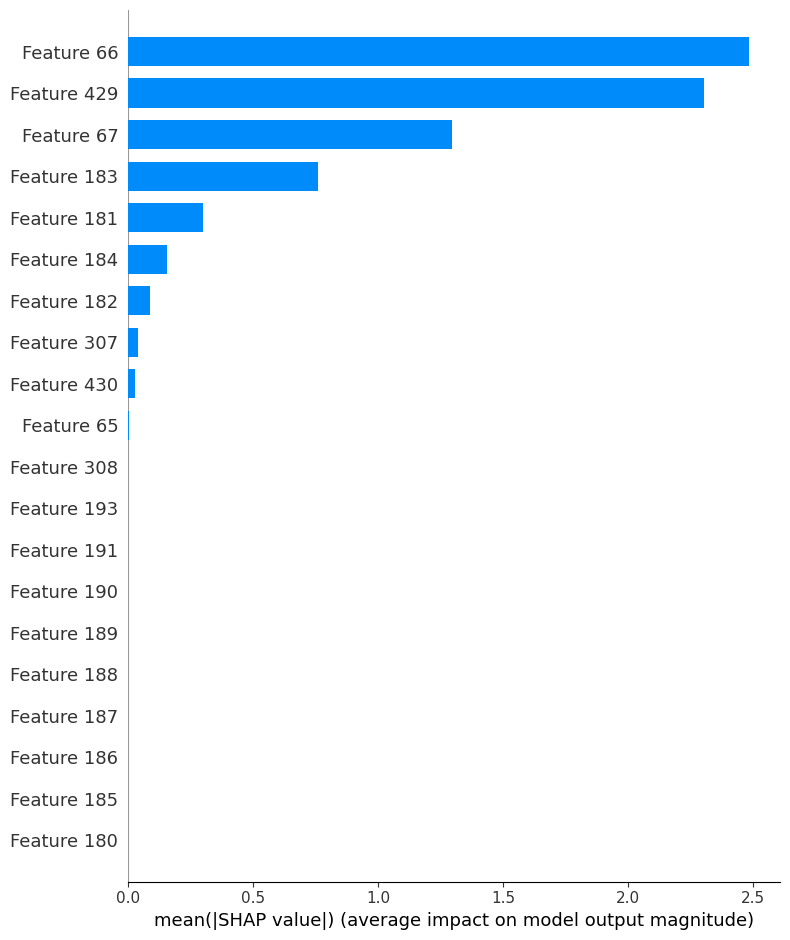

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(shap_values, X_test_final, plot_type="bar")

In [ ]:
import numpy as np

feature_names = all_features

mean_shap = np.abs(shap_values).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_shap
})

top10 = feature_importance.sort_values(
    by="importance",
    ascending=False
).head(20)

print(top10)

                    feature  importance
66           accident looks    2.484783
429                  report    2.306415
67          accident report    1.297000
183               documents    0.761454
181           documentation    0.301502
184      documents tampered    0.154151
182  documentation verified    0.087305
307                   looks    0.041040
430    report documentation    0.027219
65                 accident    0.002245
308        looks suspicious    0.000104
383                  player    0.000000
384                      pm    0.000000
382                    play    0.000000
381                   plant    0.000000
380                   place    0.000000
379                 picture    0.000000
378                    pick    0.000000
377                   phone    0.000000
376                personal    0.000000


#  Feature engineering
✔ Text intelligence (TF-IDF)
✔ Behavioral signals
✔ Target + ordinal encoding
✔ SMOTE imbalance handling
✔ XGBoost tuned via Optuna
✔ Optimal decision threshold
✔ SHAP explainability